In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pip install pandas numpy tensorflow scikit-learn matplotlib

In [10]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Reviews.csv')

In [11]:
df

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
...,...,...,...,...,...,...,...,...,...,...
568449,568450,B001EO7N10,A28KG5XORO54AY,Lettie D. Carter,0,0,5,1299628800,Will not do without,Great for sesame chicken..this is a good if no...
568450,568451,B003S1WTCU,A3I8AFVPEE8KI5,R. Sawyer,0,0,2,1331251200,disappointed,I'm disappointed with the flavor. The chocolat...
568451,568452,B004I613EE,A121AA1GQV751Z,"pksd ""pk_007""",2,2,5,1329782400,Perfect for our maltipoo,"These stars are small, so you can give 10-15 o..."
568452,568453,B004I613EE,A3IBEVCTXKNOH,"Kathy A. Welch ""katwel""",1,1,5,1331596800,Favorite Training and reward treat,These are the BEST treats for training and rew...


In [13]:
df = df[['Score', 'Text']].dropna()

# Convert to binary: 1-2 stars = negative (0), 4-5 stars = positive (1)
df = df[df['Score'] != 3]  # remove neutral
df['label'] = (df['Score'] >= 4).astype(int)
print(df['label'].value_counts())

label
1    443777
0     82037
Name: count, dtype: int64


In [14]:
# Clean, tokenize & pad sequences

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS = 10000
MAX_LEN   = 200

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(df['Text'])

sequences = tokenizer.texts_to_sequences(df['Text'])
padded    = pad_sequences(sequences, maxlen=MAX_LEN, truncating='post')

In [16]:
# Train / test split

from sklearn.model_selection import train_test_split
import numpy as np

X = padded
y = np.array(df['label'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Input

# Define model
model = Sequential([
    Input(shape=(MAX_LEN,)),

    Embedding(input_dim=MAX_WORDS, output_dim=64),

    LSTM(64, return_sequences=False),

    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

# Compile model
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Show model summary
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,089 (2.57 MB)

 Trainable params: 673,089 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Fit the model & monitor validation accuracy

history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/5
5916/5916 ━━━━━━━━━━━━━━━━━━━━ 984s 166ms/step - accuracy: 0.9332 - loss: 0.1777 - val_accuracy: 0.9504 - val_loss: 0.1326
Epoch 2/5
5916/5916 ━━━━━━━━━━━━━━━━━━━━ 975s 165ms/step - accuracy: 0.9594 - loss: 0.1126 - val_accuracy: 0.9586 - val_loss: 0.1121
Epoch 3/5
5916/5916 ━━━━━━━━━━━━━━━━━━━━ 985s 165ms/step - accuracy: 0.9694 - loss: 0.0862 - val_accuracy: 0.9597 - val_loss: 0.1068
Epoch 4/5
5916/5916 ━━━━━━━━━━━━━━━━━━━━ 974s 164ms/step - accuracy: 0.9757 - loss: 0.0693 - val_accuracy: 0.9618 - val_loss: 0.1067
Epoch 5/5
5916/5916 ━━━━━━━━━━━━━━━━━━━━ 988s 165ms/step - accuracy: 0.9809 - loss: 0.0550 - val_accuracy: 0.9631 - val_loss: 0.1188


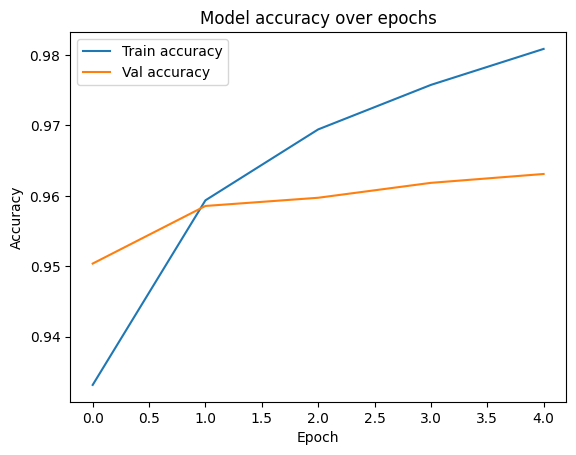

3287/3287 ━━━━━━━━━━━━━━━━━━━━ 112s 34ms/step - accuracy: 0.9644 - loss: 0.1154
Test accuracy: 0.9644


In [21]:
# Plot accuracy & loss curves


import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],     label='Train accuracy')
plt.plot(history.history['val_accuracy'], label='Val accuracy')
plt.title('Model accuracy over epochs')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(); plt.show()

loss, acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {acc:.4f}")

In [46]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).reshape(-1)

print("Test Accuracy:", test_accuracy * 100, "%")
print(classification_report(y_test, y_pred))

3287/3287 ━━━━━━━━━━━━━━━━━━━━ 114s 35ms/step
Test Accuracy: 96.31056189537048 %
              precision    recall  f1-score   support

           0       0.88      0.89      0.89     16379
           1       0.98      0.98      0.98     88784

    accuracy                           0.96    105163
   macro avg       0.93      0.93      0.93    105163
weighted avg       0.96      0.96      0.96    105163



[[14547  1832]
 [ 1913 86871]]


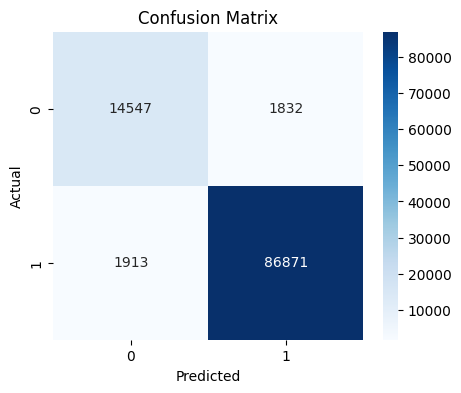

In [48]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [51]:
# Predict Sentiment for Random 10 Reviews
import random
from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_sentiment(review_text):
    seq = tokenizer.texts_to_sequences([review_text])
    pad = pad_sequences(seq, maxlen=MAX_LEN, truncating='post')
    pred = model.predict(pad, verbose=0)[0][0]
    label = "Positive" if pred >= 0.5 else "Negative"

    print(f"\nReview  : {review_text}")
    print(f"Sentiment: {label} ({pred:.2f})")

#  Pick 10 random reviews from dataset
random_reviews = df['Text'].sample(10).values

# Predict sentiment for each
for review in random_reviews:
    predict_sentiment(review)


Review  : Love Stella and Chewy's. Great for use as training treats too if you are worried about the little guy getting fat from too many treats. The goose breaks down easily. The chicken and beef are a little crumbly but that means more treats for training!
Sentiment: Positive (1.00)

Review  : with all the great reviews I though maybe this would be worth a try...Well, Not so much.<br />If your looking for something that has more of a<br />peanut butter taste spend the extra few dollars on Sunbutter made from sunflower seeds.  my Hubby who loves real PB but gave it up after we found out our daughter is allergic to peanuts would not touch this stuff but he really enjoys Sunbutter.<br />It's just not worth the money.
Sentiment: Negative (0.01)

Review  : I also purchased this potting soil and repotted all the plants in my home. Now I have gnats everywhere. I thought this was the best potting soil and paid more for it only to end up with gnats. Hundreds of them. I wish I had read the pr